# GTSRB Traffic Sign Recognition with Data Augmentation

In [1]:
import torch
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import os

import sys
sys.path.insert(1, '../util')
import vcpi_util

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

BASE_PATH     = '..'                           
PATH_TRAIN    = f'{BASE_PATH}/images/train_images'
PATH_TEST     = f'{BASE_PATH}/images/test_images'
PATH_MODELS   = f'{BASE_PATH}/models'

BATCH_SIZE = 32
EPOCHS     = 30
RUNS       = 1
NUM_CLASSES = 43  # pastas 00000 a 00042

IMG_SIZE_CONV = 32  # GTSRB usa 32x32
IMG_SIZE_VGG = 64

cuda:0


## Auxiliar Functions

In [3]:
class EarlyStopping:
    def __init__(self, patience=9, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_val_loss = float('inf')

    def __call__(self, val_loss):
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
        return False


def train(model, train_loader, val_loader, epochs, loss_fn, optimizer,
          scheduler, early_stopper, save_path):
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = np.inf

    for epoch in range(epochs):
        model.train()
        running_loss, correct = 0.0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            loss = loss_fn(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (predicted == targets).sum()

        model.eval()
        val_loss, v_correct = 0.0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_loss += loss_fn(outputs, targets).item() * targets.size(0)
                v_correct += (preds == targets).sum()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        if old_lr != new_lr:
            print(f'  LR: {old_lr} → {new_lr}')

        epoch_loss = running_loss / len(train_loader.dataset)
        acc        = 100 * correct / len(train_loader.dataset)
        v_acc      = 100 * v_correct / len(val_loader.dataset)
        val_loss  /= len(val_loader.dataset)

        history['loss'].append(epoch_loss)
        history['accuracy'].append(acc.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(v_acc.cpu().numpy())

        print(f'Epoch {epoch:03d} | Loss: {epoch_loss:.4f} | Acc: {acc:.2f}% '
              f'| Val Loss: {val_loss:.4f} | Val Acc: {v_acc:.2f}%')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'scheduler': scheduler.state_dict()}, save_path)

        if early_stopper(val_loss):
            print('Early stopping!')
            break

    print('Treino concluído.\n')
    return history


def evaluate(model, data_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, targets in data_loader:
            outputs = model(images.to(device))
            _, preds = torch.max(outputs, 1)
            correct += (preds.cpu() == targets).sum()
    return (correct / len(data_loader.dataset)).item()


def run_experiment(name, transform_train, transform_test, model_name='conv_II', n_runs=RUNS):
    print(f'\n{"="*60}')
    print(f'EXPERIÊNCIA: {name}')
    print(f'{"="*60}')

    # Divisão treino/validação (80/20) a partir do train_images
    full_train = torchvision.datasets.ImageFolder(
        root=PATH_TRAIN, transform=transform_train)
    
    val_size   = int(0.2 * len(full_train))
    train_size = len(full_train) - val_size
    train_set, val_set = torch.utils.data.random_split(
        full_train, [train_size, val_size],
        generator=torch.Generator().manual_seed(42))

    val_set.dataset.transform = transform_base_vgg if model_name in ('vgg16','vgg16_tl') else transform_base

    test_set = torchvision.datasets.ImageFolder(
        root=PATH_TEST, transform=transform_test)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = torch.utils.data.DataLoader(
        val_set,   batch_size=BATCH_SIZE)
    test_loader  = torch.utils.data.DataLoader(
        test_set,  batch_size=BATCH_SIZE)

    results = []
    for i in range(n_runs):
        print(f'\n--- Run {i+1}/{n_runs} ---')
        
        if model_name == 'conv_II':
            model = conv_II(NUM_CLASSES).to(device)
        elif model_name == 'vgg16':
            model = torchvision.models.vgg16()
            n_inputs = model.classifier[0].in_features
            model.classifier = torch.nn.Sequential(
                torch.nn.Linear(n_inputs, 256),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(256, NUM_CLASSES)
            )
            model.to(device)
        elif model_name == 'vgg16_tl':
            model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
            for param in model.parameters():
                param.requires_grad = False
            for layer in [model.features[24], model.features[26]]:
                for param in layer.parameters():
                    param.requires_grad = True
            n_inputs = model.classifier[0].in_features
            model.classifier = torch.nn.Sequential(
                torch.nn.Linear(n_inputs, 256),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(256, NUM_CLASSES)
            )
            model.to(device)
        
        loss_fn    = torch.nn.CrossEntropyLoss()
        optimizer  = torch.optim.Adam(model.parameters())
        scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                         optimizer, mode='min', factor=0.1, patience=3)
        early_stop = EarlyStopping(patience=9)
        save_path  = f'{PATH_MODELS}/{model_name}_{name}_run{i}.pt'

        history = train(model, train_loader, val_loader, EPOCHS,
                        loss_fn, optimizer, scheduler, early_stop, save_path)

        # Recarregar melhor checkpoint
        checkpoint = torch.load(save_path)
        model.load_state_dict(checkpoint['model'])
        acc = evaluate(model, test_loader)
        print(f'Test Accuracy (run {i}): {acc*100:.2f}%')
        results.append(acc)

    mean_acc = np.mean(results)
    std_acc  = np.std(results)
    print(f'\n→ {name}: média = {mean_acc*100:.2f}% | std = {std_acc*100:.2f}%')
    return results, mean_acc, std_acc


In [9]:
def build_model(model_name):
    if model_name == 'conv_II':
        return conv_II(NUM_CLASSES).to(device)
    elif model_name == 'vgg16':
        model = torchvision.models.vgg16()
        n_in = model.classifier[0].in_features
        model.classifier = torch.nn.Sequential(
            torch.nn.Linear(n_in, 256), torch.nn.ReLU(),
            torch.nn.Dropout(0.5), torch.nn.Linear(256, NUM_CLASSES)
        )
        return model.to(device)
    elif model_name == 'vgg16_tl':
        model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
        for param in model.parameters():
                param.requires_grad = False
        for layer in [model.features[24], model.features[26]]:
            for param in layer.parameters():
                param.requires_grad = True
        n_in = model.classifier[0].in_features
        model.classifier = torch.nn.Sequential(
            torch.nn.Linear(n_in, 256), torch.nn.ReLU(),
            torch.nn.Dropout(0.5), torch.nn.Linear(256, NUM_CLASSES)
        )
        return model.to(device)

## Dataset Analysis

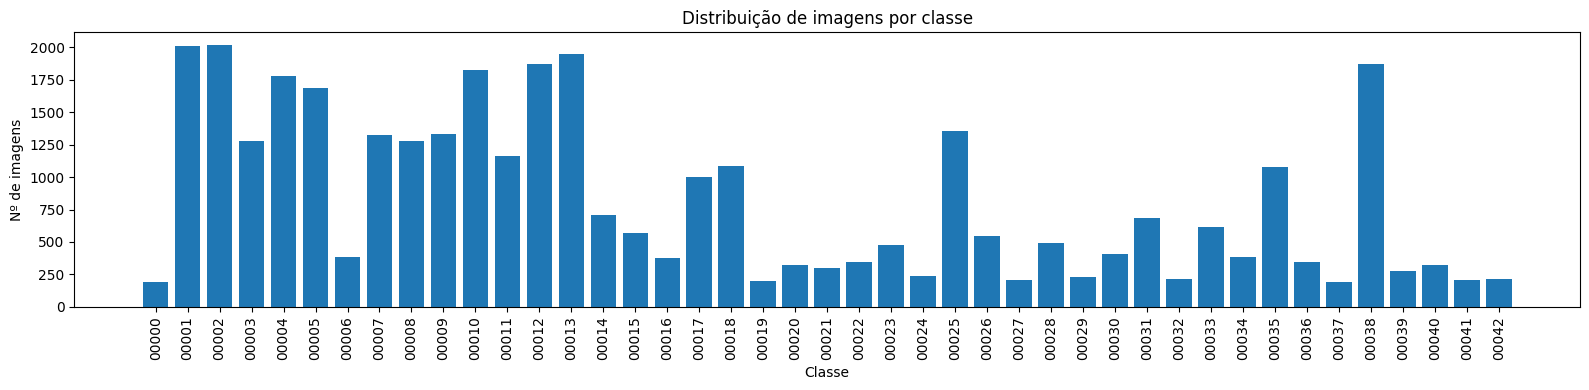

Classe com mais imagens:  00002 (2016 imgs)
Classe com menos imagens: 00000 (188 imgs)


In [4]:
from collections import Counter
import pathlib

class_counts = Counter()
for cls in sorted(os.listdir(PATH_TRAIN)):
    cls_path = os.path.join(PATH_TRAIN, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(list(pathlib.Path(cls_path).glob('*.ppm')))

plt.figure(figsize=(16,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title('Distribuição de imagens por classe')
plt.xlabel('Classe')
plt.ylabel('Nº de imagens')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Classe com mais imagens:  {max(class_counts, key=class_counts.get)} ({max(class_counts.values())} imgs)")
print(f"Classe com menos imagens: {min(class_counts, key=class_counts.get)} ({min(class_counts.values())} imgs)")

In [5]:
transform_base = v2.Compose([
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

transform_base_vgg = v2.Compose([
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

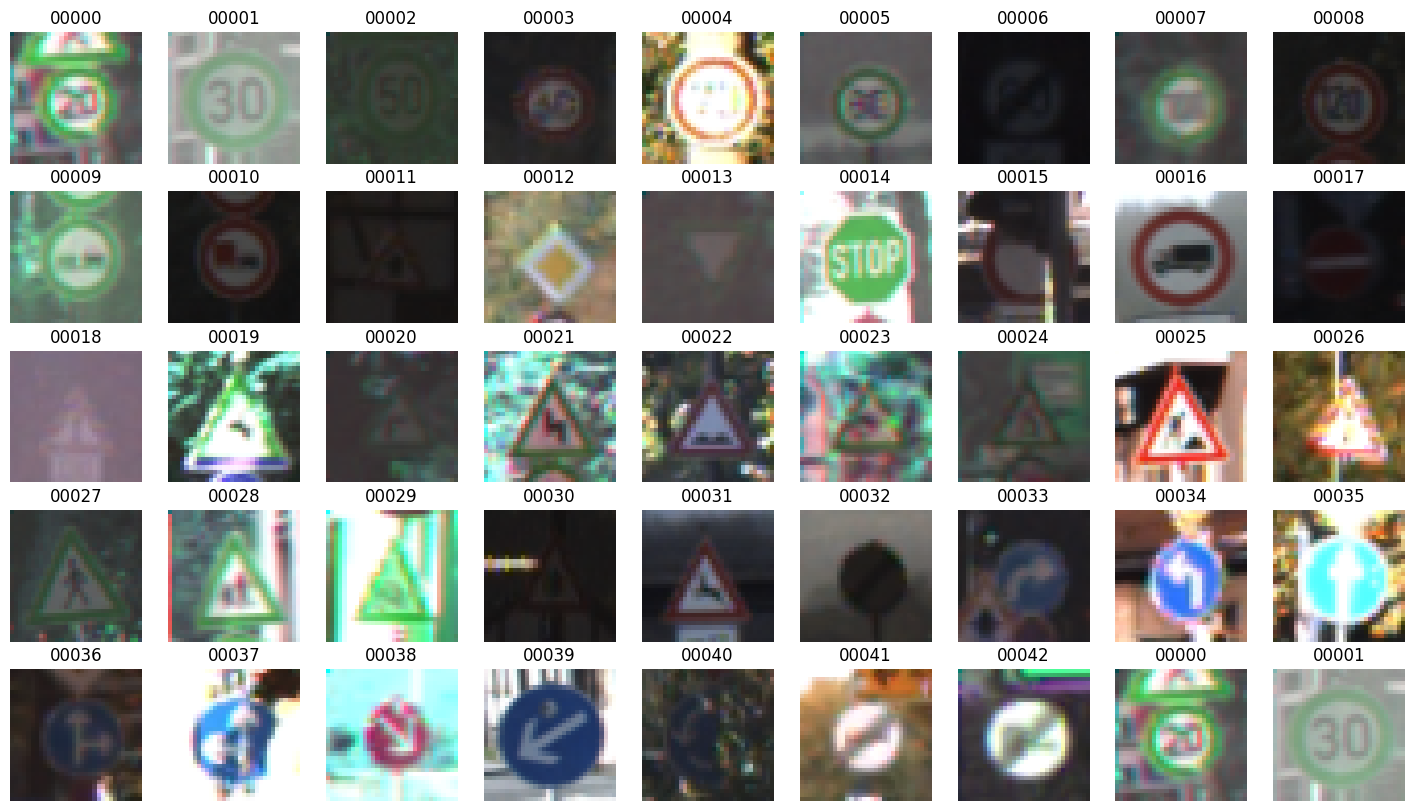

<Figure size 640x480 with 0 Axes>

In [6]:
train_set_visualization = torchvision.datasets.ImageFolder(
        root=PATH_TRAIN, transform=transform_base)

train_loader_visualization = torch.utils.data.DataLoader(
        train_set_visualization, batch_size=BATCH_SIZE, shuffle=True)

#images, targets = next(iter(train_loader_visualization))
#print("Batch shape: ", images.shape)

#print(targets)

class_to_idx = {}
for idx, (_, label) in enumerate(train_set_visualization.samples):
    if label not in class_to_idx:
        class_to_idx[label] = idx
    if len(class_to_idx) == NUM_CLASSES:
        break

indices = [class_to_idx[c] for c in sorted(class_to_idx)]
images  = torch.stack([train_set_visualization[i][0] for i in indices])
targets = torch.tensor(sorted(class_to_idx.keys()))
rows, cols = 5, 9
n = rows * cols

images_padded  = torch.cat([images,  images[:n - len(images)]])
targets_padded = torch.cat([targets, targets[:n - len(targets)]])

vcpi_util.show_images(rows, cols, images_padded, targets_padded,
                      train_set_visualization.classes)

## Model

In [11]:
class conv_II(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1   = torch.nn.Conv2d(3, 16, 3)
        self.bn1     = torch.nn.BatchNorm2d(16)
        self.relu1   = torch.nn.ReLU()
        self.conv2   = torch.nn.Conv2d(16, 32, 3)
        self.bn2     = torch.nn.BatchNorm2d(32)
        self.relu2   = torch.nn.ReLU()
        self.maxpool1 = torch.nn.MaxPool2d(2)
        self.conv3   = torch.nn.Conv2d(32, 48, 3)
        self.bn3     = torch.nn.BatchNorm2d(48)
        self.relu3   = torch.nn.ReLU()
        self.conv4   = torch.nn.Conv2d(48, 48, 3)
        self.bn4     = torch.nn.BatchNorm2d(48)
        self.relu4   = torch.nn.ReLU()
        self.maxpool2 = torch.nn.MaxPool2d(2)
        self.dropout = torch.nn.Dropout(p=0.5)
        self.fc1     = torch.nn.Linear(48, num_classes)

    def forward(self, x):
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.maxpool1(x)
        x = self.relu3(self.bn3(self.conv3(x)))
        x = self.relu4(self.bn4(self.conv4(x)))
        x = self.maxpool2(x)
        x = torch.mean(x, dim=[2, 3])  
        x = self.dropout(x)
        x = self.fc1(x)
        return x

In [8]:
all_results = []

## Experience 0 - Baseline

In [9]:
for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base = transform_base_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_base
    _, mean, std = run_experiment(
        name='baseline',
        transform_train=t_base,
        transform_test=t_base,
        model_name=model_name
    )
    all_results.append({'Modelo': model_name, 'Experiência': 'Baseline', 'Média (%)': round(mean*100,2), 'Std (%)': round(std*100,3)})


EXPERIÊNCIA: baseline

--- Run 1/1 ---
Epoch 000 | Loss: 2.5942 | Acc: 27.18% | Val Loss: 1.8031 | Val Acc: 44.93%
Epoch 001 | Loss: 1.6371 | Acc: 50.29% | Val Loss: 1.0850 | Val Acc: 71.61%
Epoch 002 | Loss: 1.0841 | Acc: 67.32% | Val Loss: 0.5748 | Val Acc: 85.06%
Epoch 003 | Loss: 0.7481 | Acc: 77.70% | Val Loss: 0.3643 | Val Acc: 91.29%
Epoch 004 | Loss: 0.5349 | Acc: 84.53% | Val Loss: 0.2318 | Val Acc: 96.80%
Epoch 005 | Loss: 0.4116 | Acc: 88.15% | Val Loss: 0.1370 | Val Acc: 97.23%
Epoch 006 | Loss: 0.3307 | Acc: 90.64% | Val Loss: 0.1304 | Val Acc: 97.99%
Epoch 007 | Loss: 0.2712 | Acc: 92.59% | Val Loss: 0.1279 | Val Acc: 97.72%
Epoch 008 | Loss: 0.2306 | Acc: 93.39% | Val Loss: 0.0544 | Val Acc: 99.18%
Epoch 009 | Loss: 0.2068 | Acc: 94.19% | Val Loss: 0.0739 | Val Acc: 99.02%
Epoch 010 | Loss: 0.1839 | Acc: 94.75% | Val Loss: 0.0465 | Val Acc: 99.00%
Epoch 011 | Loss: 0.1677 | Acc: 95.22% | Val Loss: 0.0384 | Val Acc: 99.41%
Epoch 012 | Loss: 0.1467 | Acc: 95.94% | Val Los

## Experience 1 - Augmentation Geométrica

In [10]:
transform_geo = v2.Compose([
    v2.RandomRotation(15, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

transform_geo_vgg = v2.Compose([
    v2.RandomRotation(15, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#results_geo, mean_geo, std_geo = run_experiment(
#    name='aug_geometrica',
#    transform_train=transform_geo,
#    transform_test=transform_base
#)

for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base = transform_base_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_base
    t_train = transform_geo_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_geo
    _, mean, std = run_experiment(
        name='geo',
        transform_train=t_train,
        transform_test=t_base,
        model_name=model_name
    )
    all_results.append({'Modelo': model_name, 'Experiência': 'Geométrica', 'Média (%)': round(mean*100,2), 'Std (%)': round(std*100,3)})


EXPERIÊNCIA: geo

--- Run 1/1 ---
Epoch 000 | Loss: 2.5193 | Acc: 29.46% | Val Loss: 1.7151 | Val Acc: 52.95%
Epoch 001 | Loss: 1.5867 | Acc: 51.85% | Val Loss: 1.1498 | Val Acc: 67.59%
Epoch 002 | Loss: 1.0619 | Acc: 68.20% | Val Loss: 0.5769 | Val Acc: 86.11%
Epoch 003 | Loss: 0.7404 | Acc: 78.12% | Val Loss: 0.3053 | Val Acc: 94.91%
Epoch 004 | Loss: 0.5397 | Acc: 84.42% | Val Loss: 0.2266 | Val Acc: 94.85%
Epoch 005 | Loss: 0.4107 | Acc: 88.25% | Val Loss: 0.2075 | Val Acc: 96.66%
Epoch 006 | Loss: 0.3264 | Acc: 90.67% | Val Loss: 0.0997 | Val Acc: 98.54%
Epoch 007 | Loss: 0.2777 | Acc: 92.19% | Val Loss: 0.0885 | Val Acc: 98.44%
Epoch 008 | Loss: 0.2261 | Acc: 93.55% | Val Loss: 0.0603 | Val Acc: 99.11%
Epoch 009 | Loss: 0.2061 | Acc: 94.18% | Val Loss: 0.0655 | Val Acc: 98.94%
Epoch 010 | Loss: 0.1919 | Acc: 94.45% | Val Loss: 0.0577 | Val Acc: 98.88%
Epoch 011 | Loss: 0.1663 | Acc: 95.17% | Val Loss: 0.0387 | Val Acc: 99.42%
Epoch 012 | Loss: 0.1498 | Acc: 95.75% | Val Loss: 0.

## Experience 2 - Augmentation Geométrica 2

In [11]:
transform_geo2 = v2.Compose([
    v2.RandomPerspective(distortion_scale=0.2, p=0.6),
    v2.Resize((IMG_SIZE_CONV +8, IMG_SIZE_CONV +8)),
    v2.RandomCrop((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

transform_geo2_vgg = v2.Compose([
    v2.RandomPerspective(distortion_scale=0.2, p=0.6),
    v2.Resize((IMG_SIZE_VGG +8, IMG_SIZE_VGG +8)),
    v2.RandomCrop((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#results_geo2, mean_geo2, std_geo2 = run_experiment(
#    name='aug_geometrica2',
#    transform_train=transform_geo2,
#    transform_test=transform_base
#)

for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base = transform_base_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_base
    t_train = transform_geo2_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_geo2
    _, mean, std = run_experiment(
        name='geo2',
        transform_train=t_train,
        transform_test=t_base,
        model_name=model_name
    )
    all_results.append({'Modelo': model_name, 'Experiência': 'Geométrica 2', 'Média (%)': round(mean*100,2), 'Std (%)': round(std*100,3)})


EXPERIÊNCIA: geo2

--- Run 1/1 ---
Epoch 000 | Loss: 2.5198 | Acc: 30.02% | Val Loss: 1.6757 | Val Acc: 53.30%
Epoch 001 | Loss: 1.5450 | Acc: 54.02% | Val Loss: 1.0127 | Val Acc: 71.83%
Epoch 002 | Loss: 1.0337 | Acc: 69.27% | Val Loss: 0.5564 | Val Acc: 87.06%
Epoch 003 | Loss: 0.7132 | Acc: 79.26% | Val Loss: 0.3551 | Val Acc: 93.66%
Epoch 004 | Loss: 0.5245 | Acc: 84.70% | Val Loss: 0.1591 | Val Acc: 97.18%
Epoch 005 | Loss: 0.4082 | Acc: 88.37% | Val Loss: 0.1573 | Val Acc: 97.76%
Epoch 006 | Loss: 0.3189 | Acc: 90.84% | Val Loss: 0.0831 | Val Acc: 98.71%
Epoch 007 | Loss: 0.2694 | Acc: 92.44% | Val Loss: 0.0584 | Val Acc: 99.14%
Epoch 008 | Loss: 0.2278 | Acc: 93.53% | Val Loss: 0.1063 | Val Acc: 98.06%
Epoch 009 | Loss: 0.2064 | Acc: 94.11% | Val Loss: 0.0628 | Val Acc: 98.80%
Epoch 010 | Loss: 0.1809 | Acc: 94.90% | Val Loss: 0.0654 | Val Acc: 98.74%
Epoch 011 | Loss: 0.1634 | Acc: 95.38% | Val Loss: 0.0293 | Val Acc: 99.48%
Epoch 012 | Loss: 0.1490 | Acc: 95.71% | Val Loss: 0

## Experience 3 - Augmentation de Cor

In [12]:
transform_color = v2.Compose([
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

transform_color_vgg = v2.Compose([
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#results_color, mean_color, std_color = run_experiment(
#    name='aug_cor',
#    transform_train=transform_color,
#    transform_test=transform_base
#)

for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base = transform_base_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_base
    t_train = transform_color_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_color
    _, mean, std = run_experiment(
        name='color',
        transform_train=t_train,
        transform_test=t_base,
        model_name=model_name
    )
    all_results.append({'Modelo': model_name, 'Experiência': 'Cor', 'Média (%)': round(mean*100,2), 'Std (%)': round(std*100,3)})


EXPERIÊNCIA: color

--- Run 1/1 ---
Epoch 000 | Loss: 2.4930 | Acc: 30.34% | Val Loss: 1.6972 | Val Acc: 54.48%
Epoch 001 | Loss: 1.5566 | Acc: 53.29% | Val Loss: 0.9880 | Val Acc: 73.96%
Epoch 002 | Loss: 1.0483 | Acc: 68.67% | Val Loss: 0.5886 | Val Acc: 87.25%
Epoch 003 | Loss: 0.7164 | Acc: 79.19% | Val Loss: 0.3048 | Val Acc: 92.98%
Epoch 004 | Loss: 0.5276 | Acc: 84.97% | Val Loss: 0.1873 | Val Acc: 96.87%
Epoch 005 | Loss: 0.4065 | Acc: 88.44% | Val Loss: 0.1474 | Val Acc: 97.88%
Epoch 006 | Loss: 0.3298 | Acc: 90.50% | Val Loss: 0.1290 | Val Acc: 98.10%
Epoch 007 | Loss: 0.2711 | Acc: 92.28% | Val Loss: 0.0695 | Val Acc: 98.80%
Epoch 008 | Loss: 0.2301 | Acc: 93.38% | Val Loss: 0.0609 | Val Acc: 99.11%
Epoch 009 | Loss: 0.2076 | Acc: 94.20% | Val Loss: 0.0584 | Val Acc: 99.18%
Epoch 010 | Loss: 0.1869 | Acc: 94.73% | Val Loss: 0.0620 | Val Acc: 99.24%
Epoch 011 | Loss: 0.1673 | Acc: 95.29% | Val Loss: 0.0448 | Val Acc: 99.04%
Epoch 012 | Loss: 0.1558 | Acc: 95.48% | Val Loss: 

## Experience 4 - Augmentation Combinada (geo + cor + erasing)

In [13]:
transform_combined = v2.Compose([
    v2.RandomRotation(15, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(p=0.3, scale=(0.02, 0.1), value='random')  # simula oclusão
])

transform_combined_vgg = v2.Compose([
    v2.RandomRotation(15, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(p=0.3, scale=(0.02, 0.1), value='random'),  # simula oclusão
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#results_comb, mean_comb, std_comb = run_experiment(
#    name='aug_combinada',
#    transform_train=transform_combined,
#    transform_test=transform_base
#)

for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base = transform_base_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_base
    t_train = transform_combined_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_combined
    _, mean, std = run_experiment(
        name='combined',
        transform_train=t_train,
        transform_test=t_base,
        model_name=model_name
    )
    all_results.append({'Modelo': model_name, 'Experiência': 'Combinada', 'Média (%)': round(mean*100,2), 'Std (%)': round(std*100,3)})


EXPERIÊNCIA: combined

--- Run 1/1 ---
Epoch 000 | Loss: 2.4998 | Acc: 30.00% | Val Loss: 1.6782 | Val Acc: 55.75%
Epoch 001 | Loss: 1.5315 | Acc: 53.73% | Val Loss: 0.8877 | Val Acc: 77.45%
Epoch 002 | Loss: 1.0177 | Acc: 69.61% | Val Loss: 0.5598 | Val Acc: 86.36%
Epoch 003 | Loss: 0.7100 | Acc: 78.73% | Val Loss: 0.3183 | Val Acc: 93.76%
Epoch 004 | Loss: 0.5160 | Acc: 85.03% | Val Loss: 0.1961 | Val Acc: 96.97%
Epoch 005 | Loss: 0.3894 | Acc: 89.07% | Val Loss: 0.1408 | Val Acc: 98.06%
Epoch 006 | Loss: 0.3165 | Acc: 91.07% | Val Loss: 0.0860 | Val Acc: 98.49%
Epoch 007 | Loss: 0.2568 | Acc: 92.64% | Val Loss: 0.0806 | Val Acc: 98.70%
Epoch 008 | Loss: 0.2291 | Acc: 93.50% | Val Loss: 0.0654 | Val Acc: 99.12%
Epoch 009 | Loss: 0.2004 | Acc: 94.28% | Val Loss: 0.0740 | Val Acc: 98.92%
Epoch 010 | Loss: 0.1881 | Acc: 94.71% | Val Loss: 0.0520 | Val Acc: 99.28%
Epoch 011 | Loss: 0.1561 | Acc: 95.61% | Val Loss: 0.0498 | Val Acc: 99.09%
Epoch 012 | Loss: 0.1525 | Acc: 95.75% | Val Los

## Experience 5 - Expansão Massiva do Dataset

In [23]:
transform_strong = v2.Compose([
    v2.RandomRotation(20, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(p=0.3, scale=(0.02, 0.1), value='random')
])

transform_strong_vgg = v2.Compose([
    v2.RandomRotation(20, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(p=0.3, scale=(0.02, 0.1), value='random'),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dataset expandido = original + versão augmentada
for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base   = transform_base_vgg  if model_name in ('vgg16', 'vgg16_tl') else transform_base
    t_strong = transform_strong_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_strong

    full_original  = torchvision.datasets.ImageFolder(root=PATH_TRAIN, transform=t_base)
    full_augmented = torchvision.datasets.ImageFolder(root=PATH_TRAIN, transform=t_strong)
    expanded_dataset = torch.utils.data.ConcatDataset([full_original, full_augmented])

    train_size_exp = int(0.8 * len(expanded_dataset))
    val_size_exp   = len(expanded_dataset) - train_size_exp
    train_exp, val_exp = torch.utils.data.random_split(
        expanded_dataset, [train_size_exp, val_size_exp],
        generator=torch.Generator().manual_seed(42))

    test_set = torchvision.datasets.ImageFolder(root=PATH_TEST, transform=t_base)

    train_loader_exp = torch.utils.data.DataLoader(train_exp, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_exp   = torch.utils.data.DataLoader(val_exp,   batch_size=BATCH_SIZE)
    test_loader      = torch.utils.data.DataLoader(test_set,  batch_size=BATCH_SIZE)

    results_exp = []
    for i in range(RUNS):
        print(f'\n--- Expansão Massiva [{model_name}] Run {i+1}/{RUNS} ---')
        if model_name == 'conv_II':
            model = conv_II(NUM_CLASSES).to(device)
        elif model_name == 'vgg16':
            model = torchvision.models.vgg16()
            n_inputs = model.classifier[0].in_features
            model.classifier = torch.nn.Sequential(
                torch.nn.Linear(n_inputs, 256),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(256, NUM_CLASSES)
            )
            model.to(device)
        elif model_name == 'vgg16_tl':
            model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
            for param in model.parameters():
                param.requires_grad = False
            for layer in [model.features[24], model.features[26]]:
                for param in layer.parameters():
                    param.requires_grad = True
            n_inputs = model.classifier[0].in_features
            model.classifier = torch.nn.Sequential(
                torch.nn.Linear(n_inputs, 256),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(256, NUM_CLASSES)
            )
            model.to(device)

        loss_fn    = torch.nn.CrossEntropyLoss()
        optimizer  = torch.optim.Adam(model.parameters())
        scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
        early_stop = EarlyStopping(patience=9)
        save_path  = f'{PATH_MODELS}/{model_name}_expansao_run{i}.pt'

        train(model, train_loader_exp, val_loader_exp, EPOCHS,
              loss_fn, optimizer, scheduler, early_stop, save_path)
        checkpoint = torch.load(save_path)
        model.load_state_dict(checkpoint['model'])
        acc = evaluate(model, test_loader)
        print(f'Test Accuracy: {acc*100:.2f}%')
        results_exp.append(acc)

    mean_exp = np.mean(results_exp)
    std_exp  = np.std(results_exp)
    print(f'\n→ Expansão Massiva [{model_name}]: média = {mean_exp*100:.2f}% | std = {std_exp*100:.2f}%')
    all_results.append({'Modelo': model_name, 'Experiência': 'Expansão Massiva', 'Média (%)': round(mean_exp*100,2), 'Std (%)': round(std_exp*100,3)})


--- Expansão Massiva [conv_II] Run 1/1 ---
Epoch 000 | Loss: 2.4140 | Acc: 30.97% | Val Loss: 1.4809 | Val Acc: 58.82%
Epoch 001 | Loss: 1.2991 | Acc: 60.92% | Val Loss: 0.7921 | Val Acc: 80.52%
Epoch 002 | Loss: 0.8183 | Acc: 76.02% | Val Loss: 0.4391 | Val Acc: 91.24%
Epoch 003 | Loss: 0.6067 | Acc: 82.26% | Val Loss: 0.2920 | Val Acc: 94.16%
Epoch 004 | Loss: 0.5049 | Acc: 85.25% | Val Loss: 0.2606 | Val Acc: 94.77%
Epoch 005 | Loss: 0.4349 | Acc: 87.42% | Val Loss: 0.2472 | Val Acc: 93.97%
Epoch 006 | Loss: 0.3791 | Acc: 89.12% | Val Loss: 0.1777 | Val Acc: 95.58%
Epoch 007 | Loss: 0.3522 | Acc: 89.85% | Val Loss: 0.2479 | Val Acc: 94.19%
Epoch 008 | Loss: 0.3283 | Acc: 90.49% | Val Loss: 0.1581 | Val Acc: 95.93%
Epoch 009 | Loss: 0.3072 | Acc: 90.95% | Val Loss: 0.1379 | Val Acc: 96.06%
Epoch 010 | Loss: 0.2910 | Acc: 91.66% | Val Loss: 0.1288 | Val Acc: 96.64%
Epoch 011 | Loss: 0.2780 | Acc: 92.01% | Val Loss: 0.1725 | Val Acc: 95.76%
Epoch 012 | Loss: 0.2664 | Acc: 92.11% | Val

## Experience 6 - Augmentation com MixUp e CutMix

In [15]:
def train_mixup(model, train_loader, val_loader, epochs, loss_fn, optimizer,
                scheduler, early_stopper, save_path):
    
    mixup = v2.MixUp(num_classes=NUM_CLASSES)
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = np.inf

    for epoch in range(epochs):
        model.train()
        running_loss, correct = 0.0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            # única diferença: aplica mixup ao batch antes do forward pass
            inputs, targets_mix = mixup(inputs, targets)
            
            outputs = model(inputs)
            loss = loss_fn(outputs, targets_mix)   # targets_mix são soft labels
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            # accuracy com labels originais (duras), não as soft
            _, predicted = torch.max(outputs, 1)
            hard = torch.argmax(targets_mix, dim=1)
            correct += (predicted == hard).sum()

        # validação igual ao train() original — sem mixup
        model.eval()
        val_loss, v_correct = 0.0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_loss += loss_fn(outputs,
                    torch.nn.functional.one_hot(targets, NUM_CLASSES).float()
                ).item() * targets.size(0)
                v_correct += (preds == targets).sum()

        # resto igual ao train() original
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        if old_lr != new_lr:
            print(f'  LR: {old_lr} → {new_lr}')

        epoch_loss = running_loss / len(train_loader.dataset)
        acc        = 100 * correct / len(train_loader.dataset)
        v_acc      = 100 * v_correct / len(val_loader.dataset)
        val_loss  /= len(val_loader.dataset)

        history['loss'].append(epoch_loss)
        history['accuracy'].append(acc.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(v_acc.cpu().numpy())

        print(f'Epoch {epoch:03d} | Loss: {epoch_loss:.4f} | Acc: {acc:.2f}% '
              f'| Val Loss: {val_loss:.4f} | Val Acc: {v_acc:.2f}%')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'scheduler': scheduler.state_dict()}, save_path)

        if early_stopper(val_loss):
            print('Early stopping!')
            break

    print('Treino concluído.\n')
    return history

In [16]:
def run_experiment_mix(name, transform_train, transform_test, model_name='conv_II', n_runs=RUNS):
    print(f'\n{"="*60}')
    print(f'EXPERIÊNCIA: {name}')
    print(f'{"="*60}')

    # Divisão treino/validação (80/20) a partir do train_images
    full_train = torchvision.datasets.ImageFolder(
        root=PATH_TRAIN, transform=transform_train)
    
    val_size   = int(0.2 * len(full_train))
    train_size = len(full_train) - val_size
    train_set, val_set = torch.utils.data.random_split(
        full_train, [train_size, val_size],
        generator=torch.Generator().manual_seed(42))

    val_set.dataset.transform = transform_base_vgg if model_name in ('vgg16','vgg16_tl') else transform_base

    test_set = torchvision.datasets.ImageFolder(
        root=PATH_TEST, transform=transform_test)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = torch.utils.data.DataLoader(
        val_set,   batch_size=BATCH_SIZE)
    test_loader  = torch.utils.data.DataLoader(
        test_set,  batch_size=BATCH_SIZE)

    results = []
    for i in range(n_runs):
        print(f'\n--- Run {i+1}/{n_runs} ---')

        if model_name == 'conv_II':
            model = conv_II(NUM_CLASSES).to(device)
        elif model_name == 'vgg16':
            model = torchvision.models.vgg16()
            n_inputs = model.classifier[0].in_features
            model.classifier = torch.nn.Sequential(
                torch.nn.Linear(n_inputs, 256),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(256, NUM_CLASSES)
            )
            model.to(device)
        elif model_name == 'vgg16_tl':
            model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
            for param in model.parameters():
                param.requires_grad = False
            for layer in [model.features[24], model.features[26]]:
                for param in layer.parameters():
                    param.requires_grad = True
            n_inputs = model.classifier[0].in_features
            model.classifier = torch.nn.Sequential(
                torch.nn.Linear(n_inputs, 256),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(256, NUM_CLASSES)
            )
            model.to(device)
        
        loss_fn    = torch.nn.CrossEntropyLoss()
        optimizer  = torch.optim.Adam(model.parameters())
        scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                         optimizer, mode='min', factor=0.1, patience=3)
        early_stop = EarlyStopping(patience=9)
        save_path  = f'{PATH_MODELS}/{name}_run{i}.pt'

        history = train_mixup(model, train_loader, val_loader, EPOCHS,
                        loss_fn, optimizer, scheduler, early_stop, save_path)

        # Recarregar melhor checkpoint
        checkpoint = torch.load(save_path)
        model.load_state_dict(checkpoint['model'])
        acc = evaluate(model, test_loader)
        print(f'Test Accuracy (run {i}): {acc*100:.2f}%')
        results.append(acc)

    mean_acc = np.mean(results)
    std_acc  = np.std(results)
    print(f'\n→ {name}: média = {mean_acc*100:.2f}% | std = {std_acc*100:.2f}%')
    return results, mean_acc, std_acc


In [17]:
transform_mix = v2.Compose([
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

transform_mix_vgg = v2.Compose([
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#results_mix, mean_mix, std_mix = run_experiment_mix(
#    name='aug_mix',
#    transform_train=transform_mix,
#    transform_test=transform_base
#)

for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base = transform_base_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_base
    t_train = transform_mix_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_mix
    _, mean, std = run_experiment(
        name='mix',
        transform_train=t_train,
        transform_test=t_base,
        model_name=model_name
    )
    all_results.append({'Modelo': model_name, 'Experiência': 'CutMix e MixUp', 'Média (%)': round(mean*100,2), 'Std (%)': round(std*100,3)})


EXPERIÊNCIA: mix

--- Run 1/1 ---
Epoch 000 | Loss: 2.5495 | Acc: 29.42% | Val Loss: 1.6876 | Val Acc: 52.16%
Epoch 001 | Loss: 1.5426 | Acc: 53.56% | Val Loss: 0.8936 | Val Acc: 75.48%
Epoch 002 | Loss: 1.0305 | Acc: 69.27% | Val Loss: 0.5411 | Val Acc: 87.96%
Epoch 003 | Loss: 0.7126 | Acc: 79.08% | Val Loss: 0.2928 | Val Acc: 93.85%
Epoch 004 | Loss: 0.5175 | Acc: 84.89% | Val Loss: 0.1919 | Val Acc: 96.89%
Epoch 005 | Loss: 0.3958 | Acc: 88.74% | Val Loss: 0.1432 | Val Acc: 97.96%
Epoch 006 | Loss: 0.3112 | Acc: 91.43% | Val Loss: 0.0984 | Val Acc: 98.56%
Epoch 007 | Loss: 0.2625 | Acc: 92.80% | Val Loss: 0.0640 | Val Acc: 98.54%
Epoch 008 | Loss: 0.2240 | Acc: 93.74% | Val Loss: 0.0638 | Val Acc: 98.95%
Epoch 009 | Loss: 0.1943 | Acc: 94.53% | Val Loss: 0.0495 | Val Acc: 99.32%
Epoch 010 | Loss: 0.1766 | Acc: 95.17% | Val Loss: 0.0509 | Val Acc: 99.22%
Epoch 011 | Loss: 0.1598 | Acc: 95.36% | Val Loss: 0.0457 | Val Acc: 99.00%
Epoch 012 | Loss: 0.1415 | Acc: 96.20% | Val Loss: 0.

## Tabela Comparativa de Resultados

In [29]:
summary = pd.DataFrame(all_results)

In [94]:
summary

,Modelo,Experiência,Média (%),Std (%)
0,conv_II,Baseline,97.28,0.0
1,vgg16,Baseline,5.70,0.0
2,vgg16_tl,Baseline,86.66,0.0
3,conv_II,Geométrica,96.60,0.0
4,vgg16,Geométrica,5.70,0.0
5,vgg16_tl,Geométrica,88.07,0.0
6,conv_II,Geométrica 2,97.43,0.0
7,vgg16,Geométrica 2,5.70,0.0
8,vgg16_tl,Geométrica 2,87.40,0.0
9,conv_II,Cor,97.13,0.0


Modelo            conv_II  vgg16  vgg16_tl
Experiência                               
Baseline            97.28    5.7     86.66
Combinada           97.59    5.7     86.14
Cor                 97.13    5.7     86.51
CutMix e MixUp      97.76    5.7     86.61
Expansão Massiva    98.57    5.7     89.84
Geométrica          96.60    5.7     88.07
Geométrica 2        97.43    5.7     87.40


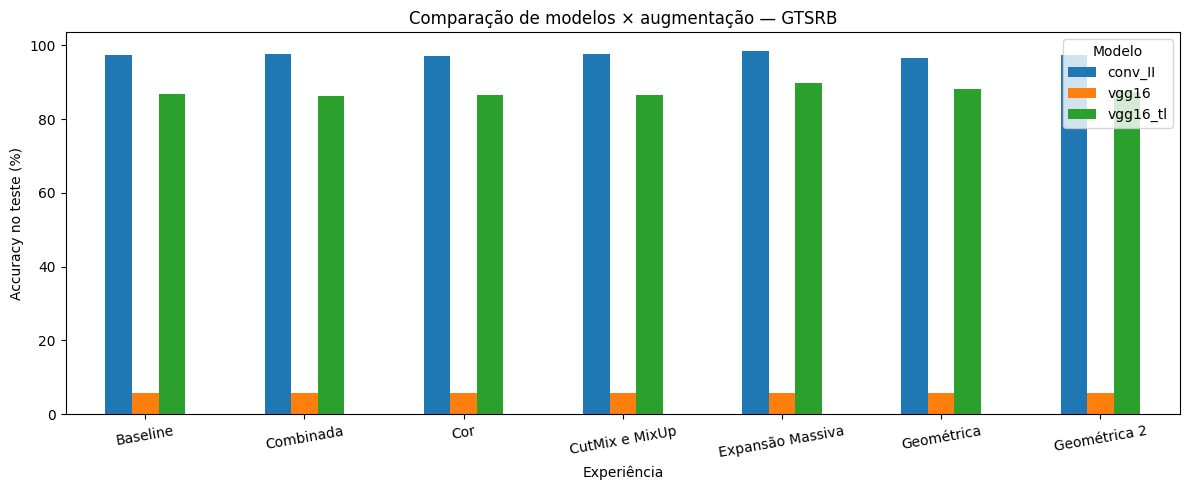

In [39]:
print(summary.pivot(index='Experiência', columns='Modelo', values='Média (%)').to_string())

pivot = summary.pivot(index='Experiência', columns='Modelo', values='Média (%)')
pivot.plot(kind='bar', figsize=(12, 5), capsize=4)
plt.ylabel('Accuracy no teste (%)')
plt.title('Comparação de modelos × augmentação — GTSRB')
plt.xticks(rotation=10)
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()

## Análise de Resultados

In [3]:
def load_model(model_name, exp_name, run):
    path = f'{PATH_MODELS}/{model_name}_{exp_name}_run{run}.pt'

    model = build_model(model_name)
    ckpt  = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model'])
    model.eval()

    return model

def build_unnormalized_confusion_matrix(model, data_loader):
    preds = []
    ground_truth = []

    model.eval()
    with torch.no_grad():

        for images, targets in data_loader:

            logits = model(images.to(device))
            preds_labels = logits.argmax(dim=1).cpu()
            preds.extend(preds_labels.tolist())
            ground_truth.extend(targets.cpu().tolist())

    num_classes = len(data_loader.dataset.classes)
    vcpi_util.show_confusion_matrix(ground_truth, preds, num_classes)

def inverse_normalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

In [4]:
def show_bad_preds_v2(model, data_loader, classes, mean=None, std=None):
    k = 0
    iters = 0
    preds = []
    ground_truth = []
    
    # inferir tamanho da imagem a partir do loader
    sample, _ = next(iter(data_loader))
    img_size = sample.shape[-1]  # altura/largura
    
    imgs = torch.zeros(52, 3, img_size, img_size)
    iterator = iter(data_loader)
    max_iters = len(data_loader)
    model.eval()
    with torch.no_grad():
        while k < 52 and iters < max_iters:
            images, targets = next(iterator)
            logits = model(images.to(device))
            predictions = torch.nn.functional.softmax(logits, dim=1).cpu().detach().numpy()
            for i in range(len(predictions)):
                if np.argmax(predictions[i]) != targets[i] and k < 52:
                    preds.append(predictions[i])
                    ground_truth.append(int(targets[i]))
                    img = images[i]
                    if mean is not None and std is not None:
                        img = inverse_normalize(img.clone(), mean, std)
                    imgs[k] = img
                    k += 1
            iters += 1
    vcpi_util.plot_predictions(imgs, preds, ground_truth, classes, 13, 4)

In [5]:
models_list = [
    ('conv_II','expansao','ConvII - Expansão Massiva'),
    ('vgg16_tl','expansao','VGG16 c/ TL - Expansão Massiva')
#    ('conv_II','expansao','ConvII - Expansão Massiva'),
#    ('vgg16_tl','expansao','VGG16 c/ TL - Expansão Massiva'),
]

--------------------------------------------------
ConvII - Expansão Massiva
--------------------------------------------------
---------- Matriz de Confusão ----------


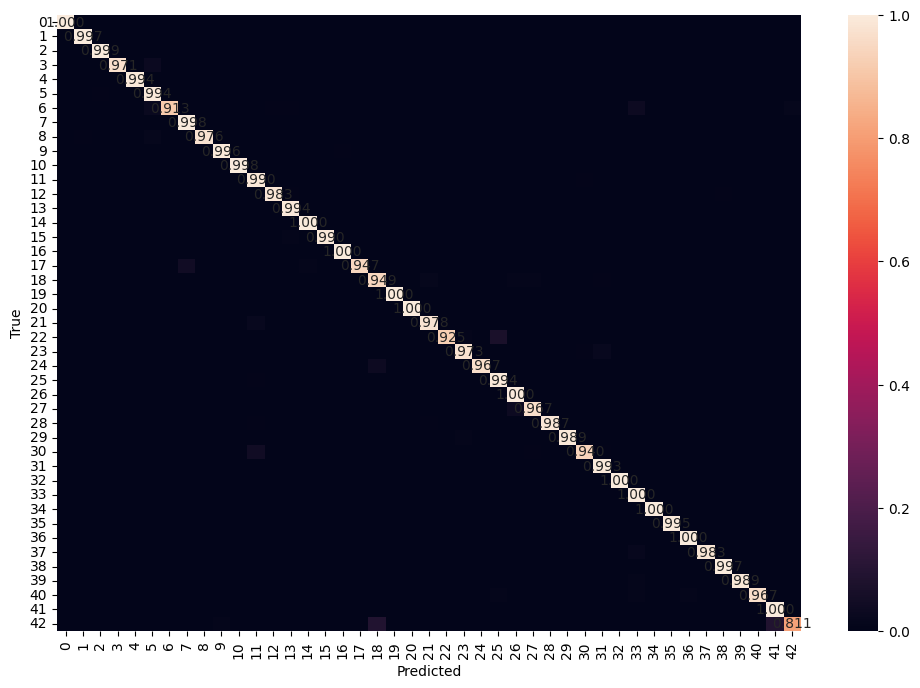

---------- Piores classificações ----------


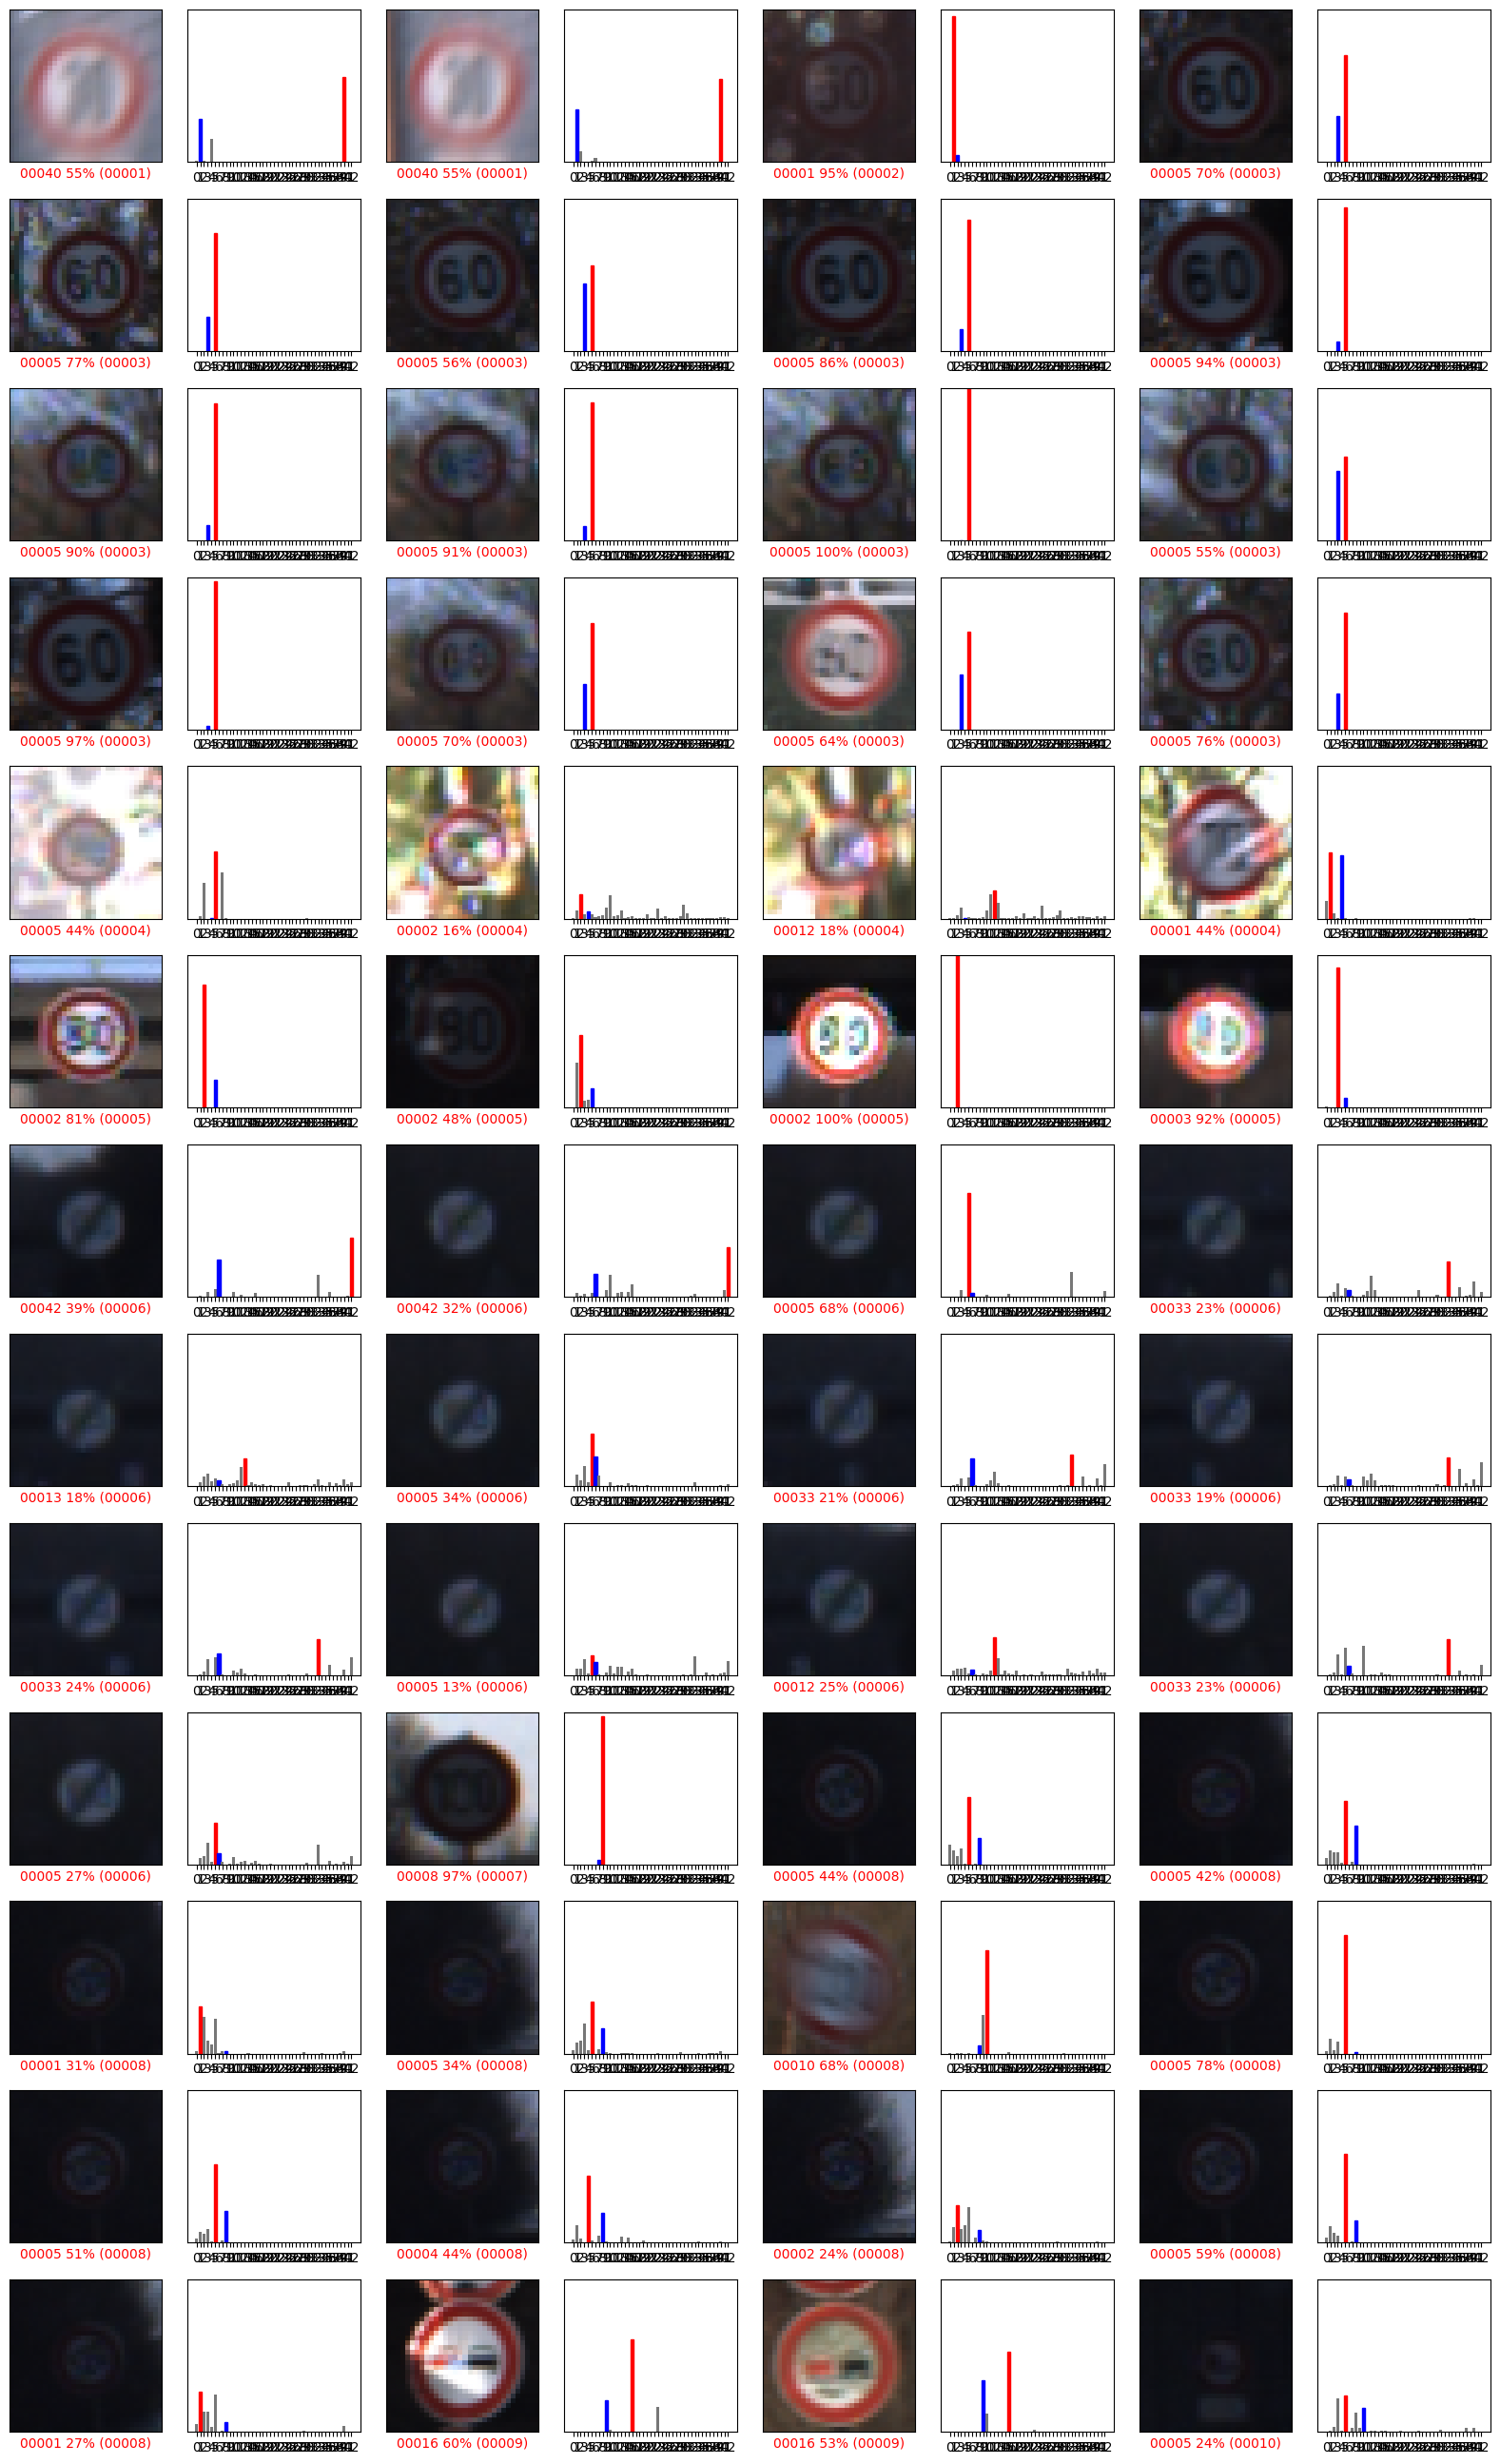

--------------------------------------------------
VGG16 c/ TL - Expansão Massiva
--------------------------------------------------


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\inesg/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100.0%


---------- Matriz de Confusão ----------


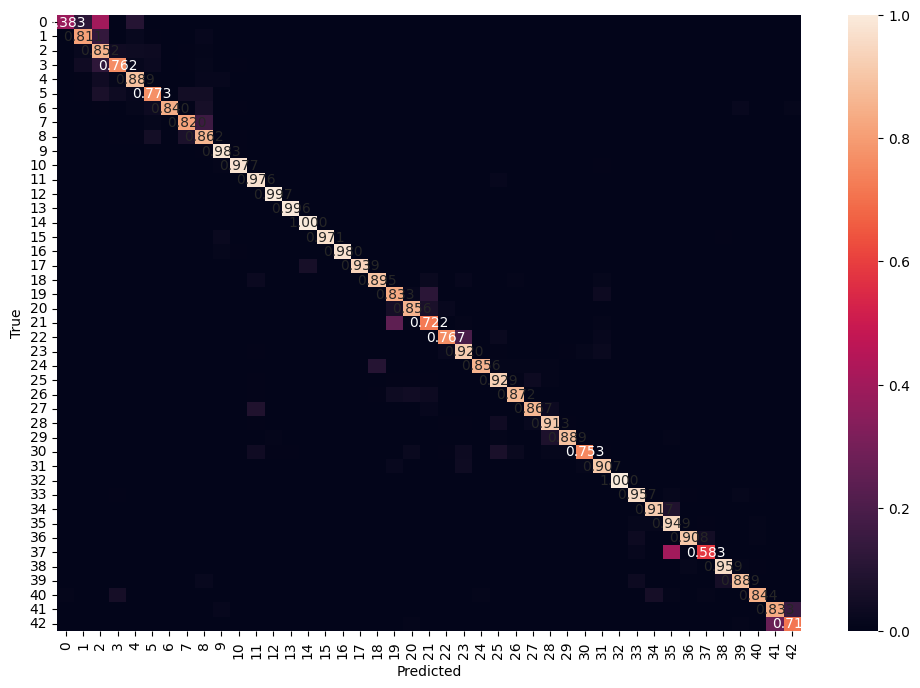

---------- Piores classificações ----------


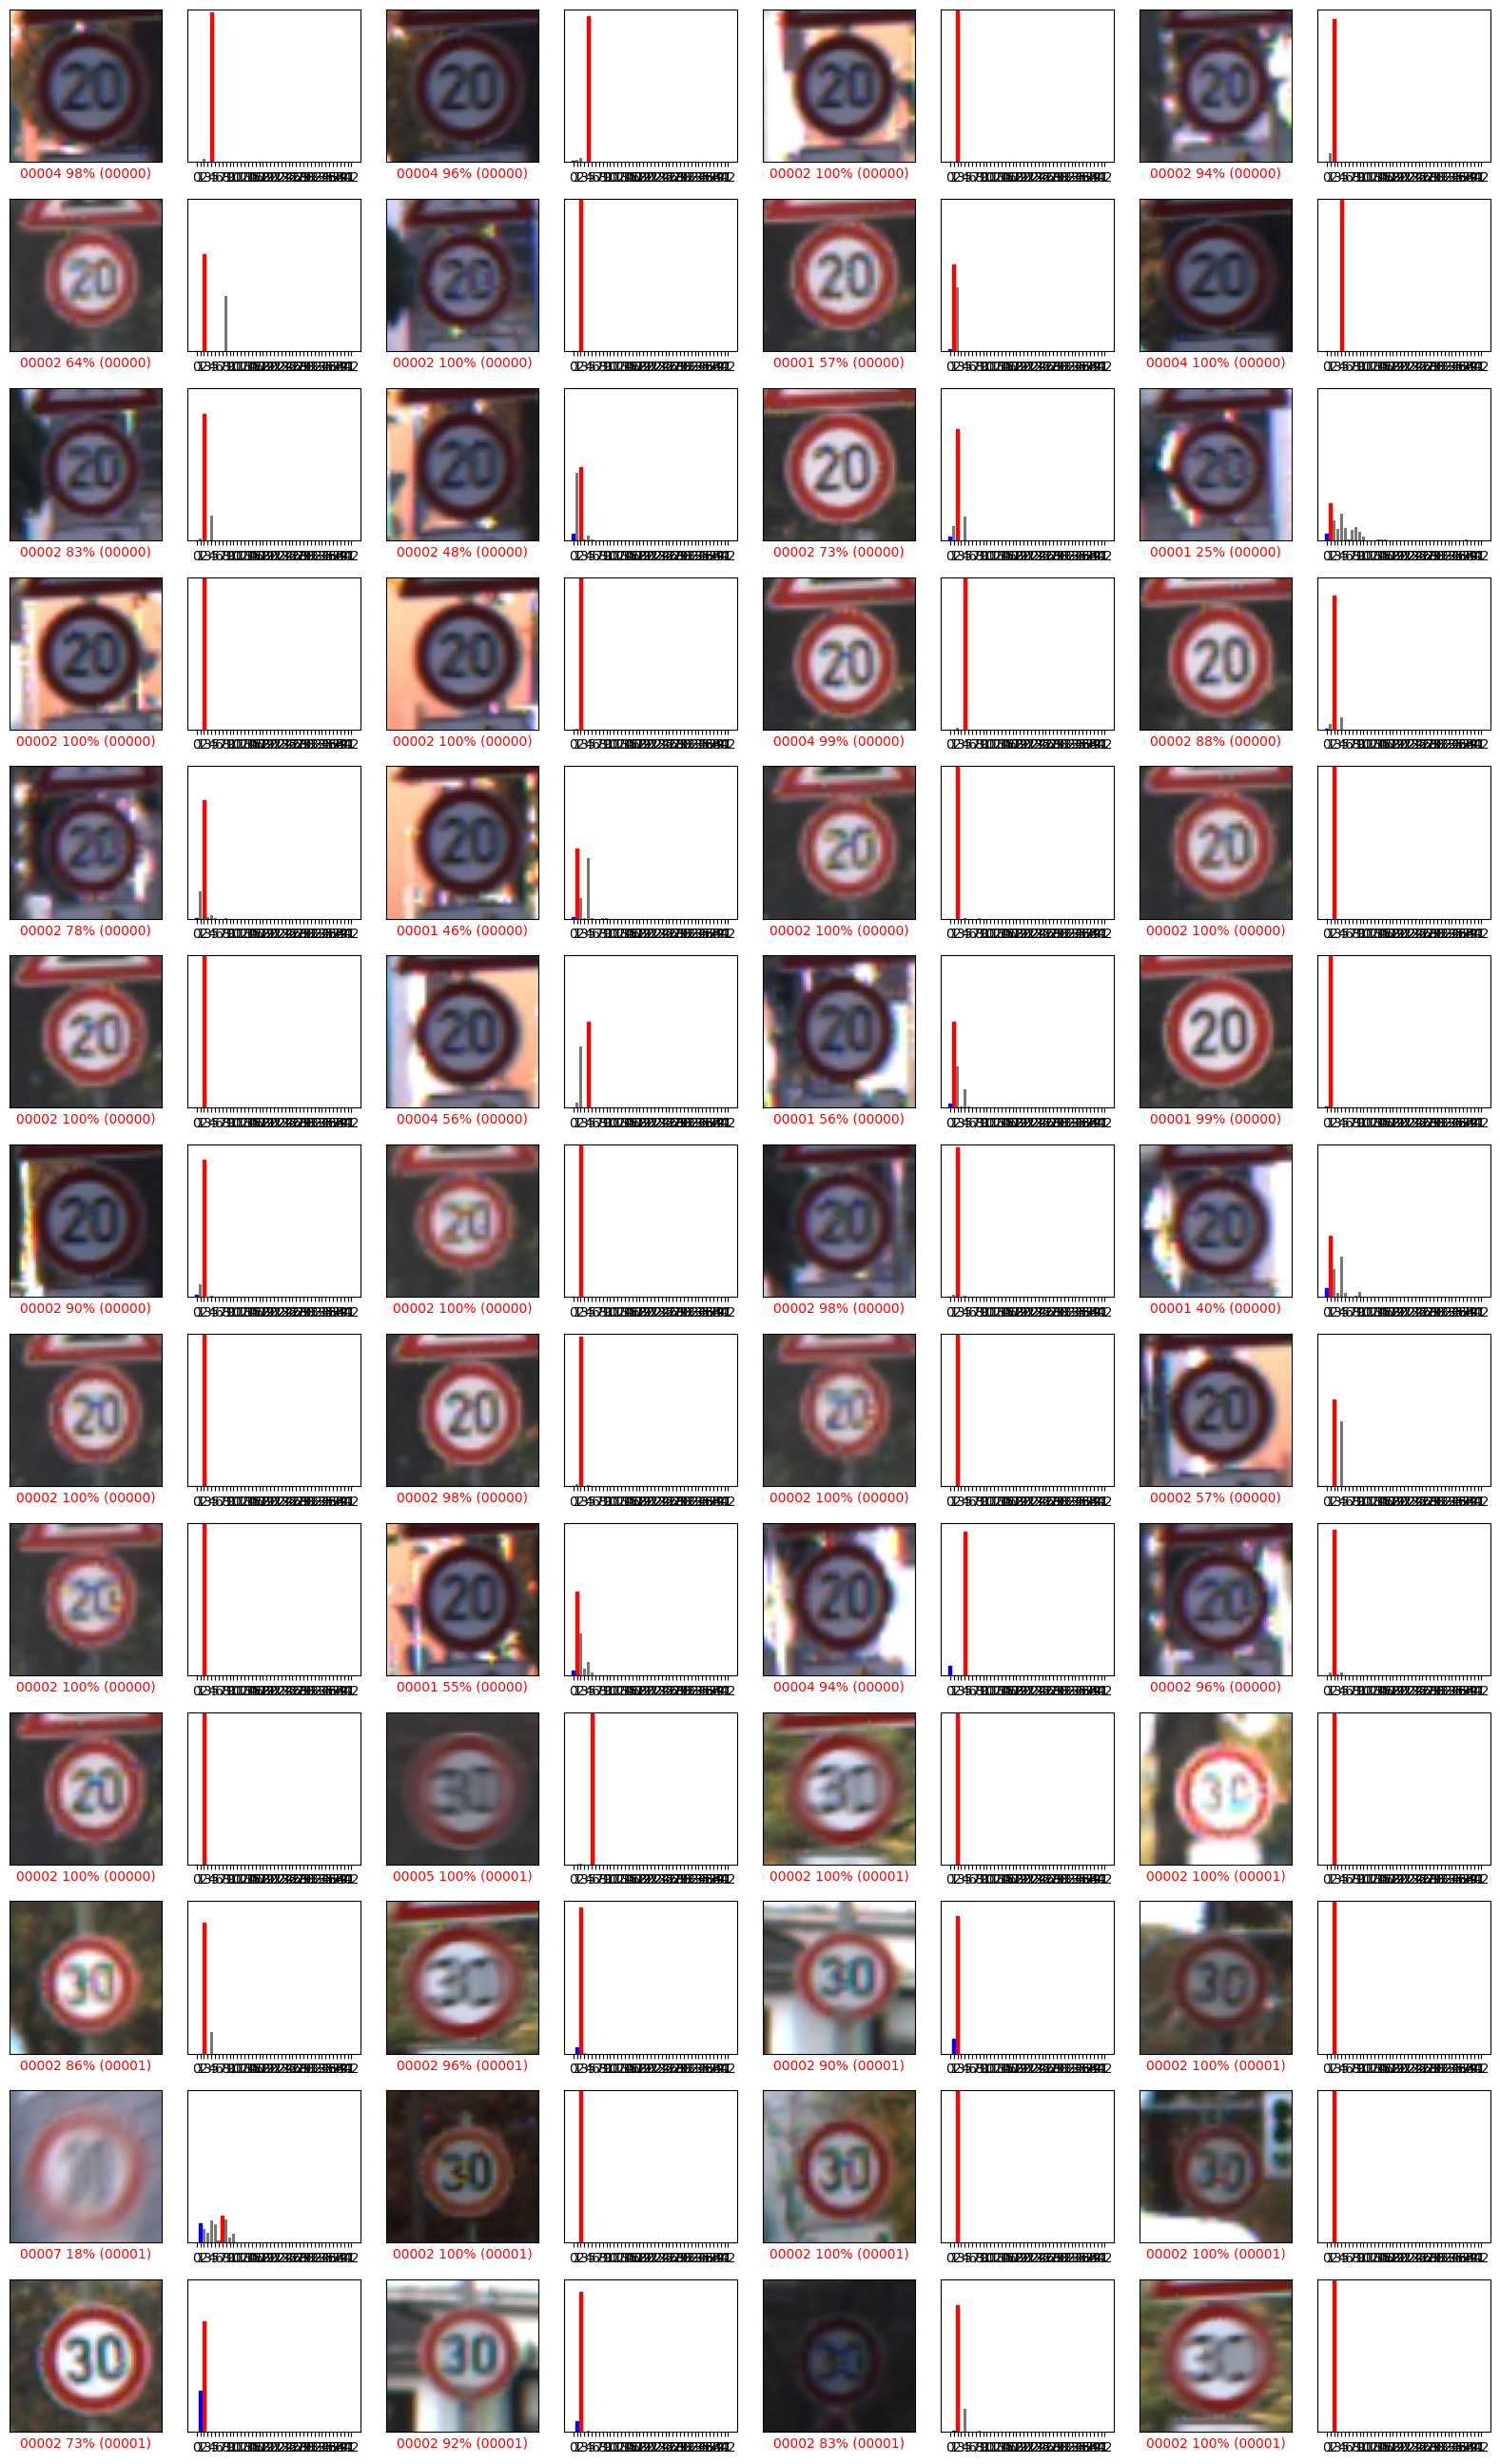

In [12]:
for model_name, exp_name, label in models_list:
    print(f'{"-"*50}')
    print(f'{label}')
    print(f'{"-"*50}')

    test_loader, _ = get_test_loader(model_name)
    model = load_model(model_name, exp_name, 0)
    
    print(f'{"-"*10} Matriz de Confusão {"-"*10}')
    build_unnormalized_confusion_matrix(model, test_loader)
    print(f'{"-"*10} Piores classificações {"-"*10}')
    if model_name == 'conv_II':
        show_bad_preds_v2(model, test_loader, test_loader.dataset.classes)
    else:
        show_bad_preds_v2(model, test_loader, test_loader.dataset.classes, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

---
# Parte 2 – Ensemble

## Ensemble configuration

In [7]:
ENSEMBLE_RUNS = RUNS

transform_ensemble_conv = v2.Compose([
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

transform_ensemble_vgg = v2.Compose([
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_test_loader(model_name):
    transform = transform_ensemble_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_ensemble_conv
    test_set = torchvision.datasets.ImageFolder(root=PATH_TEST, transform=transform)
    return torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False), len(test_set)

loader_conv, n_test_conv = get_test_loader('conv_II')
print(f'Test samples (conv_II): {n_test_conv}')
loader_vgg, n_test_vgg = get_test_loader('vgg16')
print(f'Test samples (vgg16/vgg16_tl): {n_test_vgg}')

Test samples (conv_II): 12630
Test samples (vgg16/vgg16_tl): 12630


## Auxiliary functions for ensemble evaluation

In [72]:
def load_ensemble_models(models_ensemble_list):
    models = []
    accs_conv   = []
    accs_vgg   = []

    for model_name, exp_name, i in models_ensemble_list:
        path = f'{PATH_MODELS}/{model_name}_{exp_name}_run{i}.pt'

        if not os.path.exists(path):
            print(f'  [WARNING] Checkpoint not found: {path} — skipped')
            continue

        model = build_model(model_name)
        ckpt  = torch.load(path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model'])
        model.eval()

        #acc = evaluate(model, loader)
        models.append((model_name, model))
        #accs.append(acc)
        #print(f'  Run {i}: accuracy = {acc:.4f}')

    #if accs:
    #    print(f'  Individual mean: {np.mean(accs):.4f}  |  Std: {np.std(accs):.4f}')
    return models




def get_labels_logits_and_preds(models):
    labels  = None
    logits  = []
    preds   = []

    for model_name, model in models:
        loader, _ = get_test_loader(model_name)
        model_logits = []
        model_preds  = []
        batch_labels = []

        with torch.no_grad():
            for inputs, targets in loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                model_logits.extend(outputs.cpu())
                model_preds.extend(outputs.argmax(dim=1).cpu())
                batch_labels.extend(targets.tolist())

        if labels is None:
            labels = batch_labels
            
        logits.append(model_logits)
        preds.append(model_preds)

    return labels, logits, preds

## Soft Voting Ensemble

In [73]:
def soft_voting_accuracy(labels, logits):
    num_samples = len(logits[0])
    soft_preds  = []
    
    for s in range(num_samples):
        summed = torch.zeros(NUM_CLASSES)
        for run_logits in logits:
            summed += run_logits[s]
        soft_preds.append(torch.argmax(summed).item())
    return sum(y == p for y, p in zip(labels, soft_preds)) / len(labels)

## Hard Voting Ensemble

In [74]:
def hard_voting_accuracy(labels, preds):
    from collections import Counter
    hard_preds = []
    for s in range(len(labels)):
        votes = [preds[r][s].item() for r in range(len(preds))]
        hard_preds.append(Counter(votes).most_common(1)[0][0])
    return sum(y == p for y, p in zip(labels, hard_preds)) / len(labels)

## Run Ensemble

In [99]:
ensembles_to_test = [
    {
        'label': 'conv_II + vgg16_tl (baseline)',
        'models': [('conv_II','baseline',0), ('vgg16_tl','baseline',0)]
    },
    # convII e VGG16 com os vários experimentos
    {
        'label': 'conv_II: baseline + geo + geo2 + color + combined + mix + expansao',
        'models': [('conv_II','baseline',0), ('conv_II','geo',0), ('conv_II','geo2',0), ('conv_II','color',0), ('conv_II','combined',0), ('conv_II','mix',0), ('conv_II','expansao',0)]
    },
    {
        'label': 'vgg16: baseline + geo + geo2 + color + combined + mix + expansao',
        'models': [('vgg16_tl','baseline',0), ('vgg16_tl','geo',0), ('vgg16_tl','geo2',0), ('vgg16_tl','color',0), ('vgg16_tl','combined',0), ('vgg16_tl','mix',0), ('vgg16_tl','expansao',0)]
    },
    # ensembles com os experimentos de melhor performance de cada modelo
    {
        'label': 'conv_II (expansao) + vgg16_tl (expansao)',
        'models': [('conv_II','expansao',0), ('vgg16_tl','expansao',0), ('conv_II','mix',0), ('vgg16_tl','geo',0)]
    },
    # ensembles com os experimentos de pior performance de cada modelo
    {
        'label': 'conv_II (geo) + vgg16_tl (combined)',
        'models': [('conv_II','geo',0), ('vgg16_tl','combined',0)]
    }
]

ensemble_results = []
for ens in ensembles_to_test:
    model_list = load_ensemble_models(ens['models'])
    labels, logits, preds_list = get_labels_logits_and_preds(model_list)
    soft_acc = soft_voting_accuracy(labels, logits)
    hard_acc = hard_voting_accuracy(labels, preds_list)
    ensemble_results.append({
        'Ensemble':          ens['label'],
        'Soft Voting (%)':   round(soft_acc*100, 2),
        'Hard Voting (%)':   round(hard_acc*100, 2),
    })

ensemble_df = pd.DataFrame(ensemble_results)

In [100]:
ensemble_df

,Ensemble,Soft Voting (%),Hard Voting (%)
0,conv_II + vgg16_tl (baseline),96.33,97.28
1,conv_II: baseline + geo + geo2 + color + combi...,98.57,98.49
2,vgg16: baseline + geo + geo2 + color + combine...,91.11,91.01
3,conv_II (expansao) + vgg16_tl (expansao),97.61,98.80
4,conv_II (geo) + vgg16_tl (combined),96.53,96.60


## Visualization Ensemble Results

In [101]:
def analyse_ensemble(labels, logits, preds_list, ens_label):
    n_samples = len(labels)

    # transpor preds: [modelo][sample] → [sample][modelo]
    preds_by_sample = [
        [preds_list[r][s].item() for r in range(len(preds_list))]
        for s in range(n_samples)
    ]

    # soft vote por sample
    soft_by_sample = []
    for s in range(n_samples):
        summed = torch.zeros(NUM_CLASSES)
        for run_logits in logits:
            summed += run_logits[s]
        soft_by_sample.append(torch.argmax(summed).item())

    test_loader_vis, _ = get_test_loader('conv_II')
    test_set_vis = test_loader_vis.dataset

    def show_example(idx, title):
        img, _ = test_set_vis[idx]
        img_np = img.permute(1, 2, 0).numpy().clip(0, 1)
        plt.imshow(img_np)
        plt.axis('off')
        plt.title(title)
        plt.show()

    def format_case(idx):
        true = labels[idx]
        return (
            f"Index: {idx}\n"
            f"True label: {true} ({test_set_vis.classes[true]})\n"
            f"Per-model predictions: {preds_by_sample[idx]}\n"
            f"Soft-vote prediction: {soft_by_sample[idx]} ({test_set_vis.classes[soft_by_sample[idx]]})"
        )

    print(f'\n{"="*55}')
    print(f'  {ens_label}')
    print(f'{"="*55}')

    # ensemble corrige pelo menos um modelo errado
    fix_idx = next(
        (i for i in range(n_samples)
         if soft_by_sample[i] == labels[i]
         and any(p != labels[i] for p in preds_by_sample[i])),
        None
    )
    if fix_idx is not None:
        print("\nEnsemble CORRIGE erros:\n")
        print(format_case(fix_idx))
        show_example(fix_idx, f"[{ens_label}] Ensemble corrige pelo menos um modelo")
    else:
        print("Sem exemplos onde o ensemble corrija erros individuais.")

    # maioria (hard) erra, mas pelo menos um modelo acerta
    worsen_idx = next(
        (i for i in range(n_samples)
         if Counter(preds_by_sample[i]).most_common(1)[0][0] != labels[i]
         and any(p == labels[i] for p in preds_by_sample[i])),
        None
    )
    if worsen_idx is not None:
        print("\nEnsemble AMPLIFICA erros:\n")
        print(format_case(worsen_idx))
        show_example(worsen_idx, f"[{ens_label}] Maioria errada, algum modelo acerta")
    else:
        print("Sem exemplos onde o ensemble amplifique erros.")


  conv_II + vgg16_tl (baseline)

Ensemble CORRIGE erros:

Index: 0
True label: 0 (00000)
Per-model predictions: [0, 2]
Soft-vote prediction: 0 (00000)


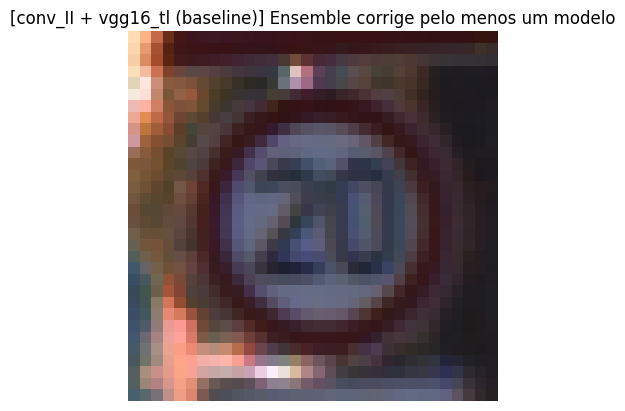


Ensemble AMPLIFICA erros:

Index: 97
True label: 1 (00001)
Per-model predictions: [2, 1]
Soft-vote prediction: 1 (00001)


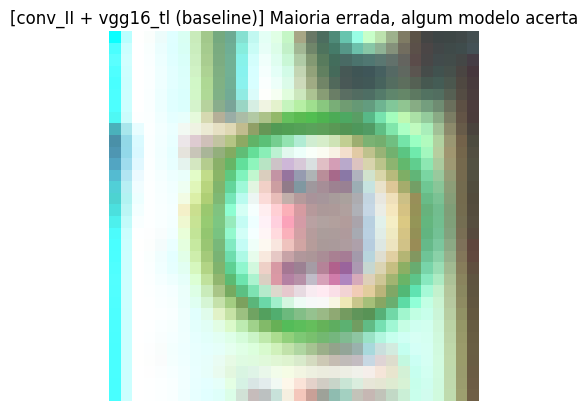


  conv_II: baseline + geo + geo2 + color + combined + mix + expansao

Ensemble CORRIGE erros:

Index: 50
True label: 0 (00000)
Per-model predictions: [4, 0, 0, 0, 0, 0, 0]
Soft-vote prediction: 0 (00000)


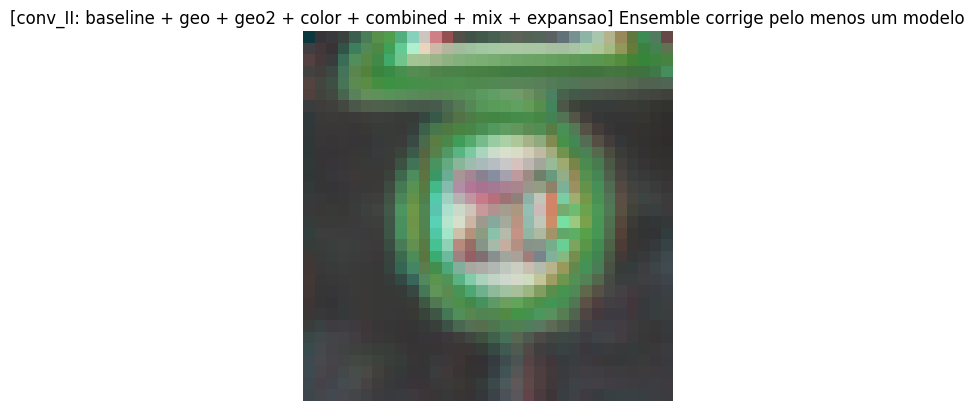


Ensemble AMPLIFICA erros:

Index: 83
True label: 1 (00001)
Per-model predictions: [1, 6, 4, 25, 40, 6, 40]
Soft-vote prediction: 1 (00001)


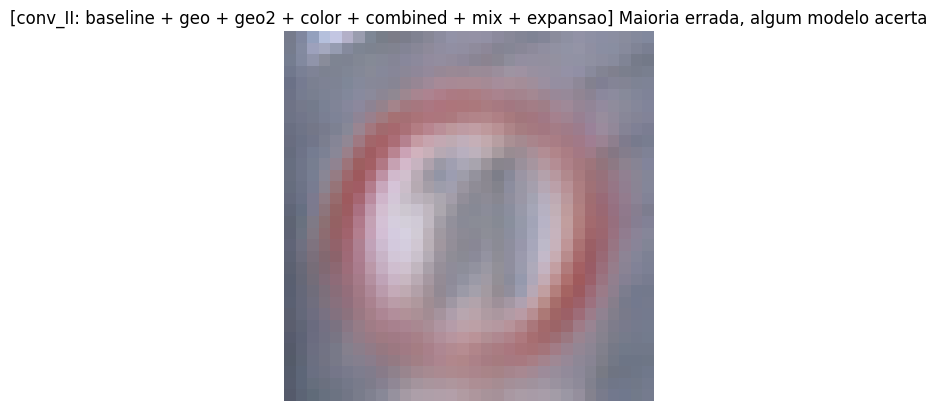


  vgg16: baseline + geo + geo2 + color + combined + mix + expansao

Ensemble CORRIGE erros:

Index: 1
True label: 0 (00000)
Per-model predictions: [0, 8, 1, 1, 2, 0, 0]
Soft-vote prediction: 0 (00000)


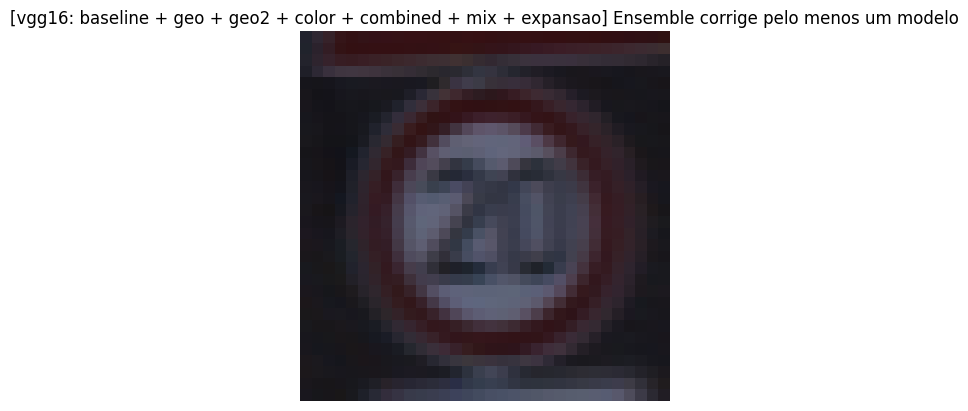


Ensemble AMPLIFICA erros:

Index: 36
True label: 0 (00000)
Per-model predictions: [2, 4, 2, 0, 2, 2, 4]
Soft-vote prediction: 2 (00002)


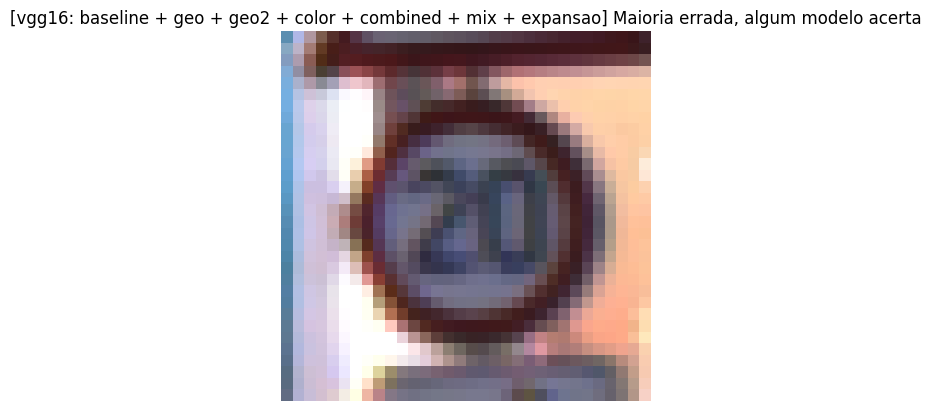


  conv_II (expansao) + vgg16_tl (expansao)

Ensemble CORRIGE erros:

Index: 0
True label: 0 (00000)
Per-model predictions: [0, 4, 0, 4]
Soft-vote prediction: 0 (00000)


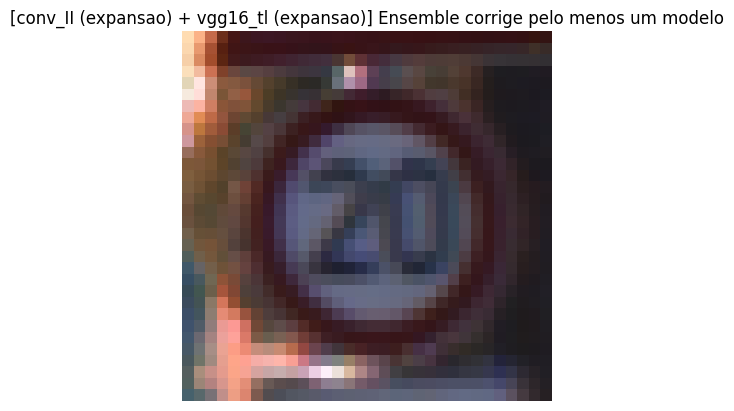


Ensemble AMPLIFICA erros:

Index: 300
True label: 1 (00001)
Per-model predictions: [1, 8, 4, 8]
Soft-vote prediction: 8 (00008)


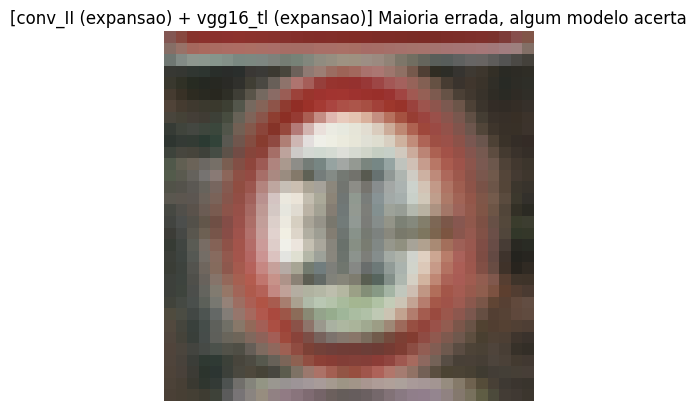


  conv_II (geo) + vgg16_tl (combined)

Ensemble CORRIGE erros:

Index: 1
True label: 0 (00000)
Per-model predictions: [0, 2]
Soft-vote prediction: 0 (00000)


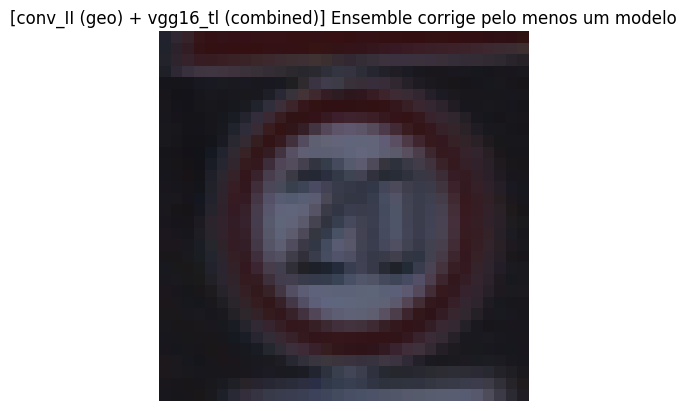


Ensemble AMPLIFICA erros:

Index: 512
True label: 1 (00001)
Per-model predictions: [12, 1]
Soft-vote prediction: 1 (00001)


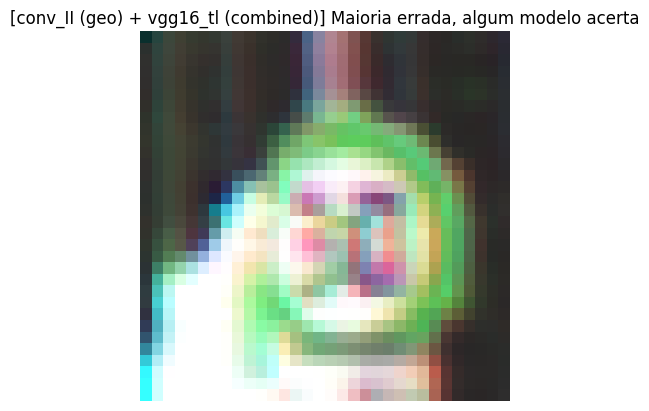

In [102]:
for ens in ensembles_to_test:
    model_list = load_ensemble_models(ens['models'])
    labels, logits, preds_list = get_labels_logits_and_preds(model_list)
    soft_acc = soft_voting_accuracy(labels, logits)
    hard_acc = hard_voting_accuracy(labels, preds_list)

    analyse_ensemble(labels, logits, preds_list, ens['label'])